In [1]:
pip install fastf1

Note: you may need to restart the kernel to use updated packages.


In [3]:
import fastf1
import pandas as pd
import numpy as np
import os
import time
import socket

socket.setdefaulttimeout(30.0)
os.makedirs('f1_cache', exist_ok=True)
fastf1.Cache.enable_cache('f1_cache')
TARGET_YEAR = 2025
print(f"Fetching schedule for the {TARGET_YEAR} season...")
schedule = fastf1.get_event_schedule(TARGET_YEAR)

all_races = []

for index, event in schedule.iterrows():
    if event['EventFormat'] == 'testing':
        continue
        
    event_name = event['EventName']
    print(f"\n--- Processing: {event_name} ---")
    
    max_retries = 3
    race_success = False
    
    for attempt in range(max_retries):
        try:
            print(f"  -> Attempt {attempt + 1}: Downloading data...")
            session = fastf1.get_session(TARGET_YEAR, event_name, 'R')
            session.load(telemetry=False, weather=True) 
            
            # --- CRITICAL ML FILTER ---
            # pick_track_status('1') removes Safety Car and VSC laps. 
            # We only want pure racing laps to model true tire degradation.
            laps = session.laps.pick_track_status('1')
            
            # Remove the actual pit-in and pit-out laps (since pit lane speed limits ruin the lap time)
            laps = laps[(laps['PitInTime'].isnull()) & (laps['PitOutTime'].isnull())]
            
            weather = laps.get_weather_data()
            
            # Reset indices for clean merge
            laps_clean = laps.reset_index(drop=True)
            weather_clean = weather.reset_index(drop=True)
            dataset = pd.concat([laps_clean, weather_clean], axis=1)
            
            # --- TARGET VARIABLE: LAP TIME IN SECONDS ---
            # Converts FastF1's timedelta object into a float (e.g., 94.234 seconds)
            dataset['LapTime_s'] = dataset['LapTime'].dt.total_seconds()
            
            # NEW CORRECTED CODE
            # We pull TyreLife directly from the FIA sensor
            features = ['Driver', 'TyreLife', 'Compound', 'TrackTemp', 'AirTemp', 'Rainfall', 'LapTime_s']
            race_data = dataset[features].copy()

            # Add the track name
            race_data['Track'] = event_name

            # Rename TyreLife to TireAge so it matches your dataset structure
            race_data = race_data.rename(columns={'TyreLife': 'TireAge'})
            
            # FIX RAINFALL NOISE (3-Lap Rolling Window)
            race_data['Rainfall'] = race_data['Rainfall'].astype(float).rolling(window=3, min_periods=1).max()
            
            all_races.append(race_data)
            print("  -> ✅ Race successfully processed!")
            race_success = True
            
            time.sleep(5) 
            break 
            
        except Exception as e:
            print(f"  -> ⚠️ Attempt {attempt + 1} failed: {e}")
            time.sleep(5) 
            
    if not race_success:
        print(f"  -> ❌ ERROR: Skipping {event_name} after {max_retries} failed attempts.")

# ---------------------------------------------------------
# MASTER CLEANING & EXPORT
# ---------------------------------------------------------
print("\nCombining and cleaning all season data...")
final_data = pd.concat(all_races, ignore_index=True)

# Clean text-based NaNs and empty strings
final_data = final_data.replace(r'^\s*$', np.nan, regex=True)
final_data = final_data.replace(['nan', 'NaN', 'None', 'null'], np.nan)

# Drop any row with missing values (including failed lap times)
final_data = final_data.dropna()

# Reorder columns for the C++ parser
final_data = final_data[['Track', 'Driver', 'Compound', 'TireAge', 
                         'TrackTemp', 'AirTemp', 'Rainfall', 'LapTime_s']]

csv_filename = f'f1_regression_data_{TARGET_YEAR}.csv'
final_data.to_csv(csv_filename, index=False)

print(f"\n✅ Success! Regression dataset saved to:\n{os.path.abspath(csv_filename)}\n")

Fetching schedule for the 2025 season...


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'



--- Processing: Australian Grand Prix ---
  -> Attempt 1: Downloading data...


core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']


  -> ✅ Race successfully processed!


...

  -> ✅ Race successfully processed!


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...



--- Processing: Abu Dhabi Grand Prix ---
  -> Attempt 1: Downloading data...


req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


  -> ✅ Race successfully processed!

Combining and cleaning all season data...

✅ Success! Regression dataset saved to:
/Users/yashvardhank/ML_Project/f1_regression_data_2025.csv



In [5]:
import sys
!{sys.executable} -m pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 11.9 MB/s  0:00:00 6.8 MB/s eta 0:00:01


In [10]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib

# 1. Load the dataset 
# (Make sure this matches the filename from the extraction script)
df = pd.read_csv('f1_regression_data_2025.csv')

# 2. ENCODING: Convert text to numbers
# get_dummies creates binary columns for every Track, Driver, and Compound
df_encoded = pd.get_dummies(df, columns=['Track', 'Driver', 'Compound'])

# 3. SPLITTING: Separate Features (X) and Target (y)
X = df_encoded.drop(columns=['LapTime_s'])
y = df_encoded['LapTime_s']

# Sequential split (No shuffling to prevent time-series data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# 4. INITIALIZE AND TRAIN XGBOOST
print("Training the XGBoost model...")
# n_estimators=500 and learning_rate=0.05 are strong starting parameters for F1 data
xgb_model = xgb.XGBRegressor(
    n_estimators=936,
    learning_rate=0.04261542261282017,
    max_depth=9,
    random_state=42,
    n_jobs=-1 # Uses all your Mac's CPU cores to train faster
)

xgb_model.fit(X_train, y_train)

# 5. EVALUATE THE MODEL
predictions = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"✅ Model trained! Mean Absolute Error: {mae:.3f} seconds per lap.")

# 6. EXPORT FOR STREAMLIT FRONTEND
# Save the model itself
joblib.dump(xgb_model, 'xgboost_f1_model.pkl')

# Save the exact list of columns so Streamlit knows how to format user input
expected_columns = X_train.columns.tolist()
joblib.dump(expected_columns, 'model_columns.pkl')

print("Model and column structure saved successfully for the web app!")

Training the XGBoost model...
✅ Model trained! Mean Absolute Error: 0.414 seconds per lap.
Model and column structure saved successfully for the web app!


In [8]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [9]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# 1. Define the "Objective Function" (The arena where Optuna tests the models)
def objective(trial):
    # Define the continuous search space
    # log=True is used for learning rate so it searches efficiently across magnitudes
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        
        # Adding a new parameter! Subsample randomly drops a % of data per tree to prevent overfitting
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        
        'random_state': 42,
        'n_jobs': -1  # Let XGBoost use your Mac's M4 cores
    }
    
    # Build the model with the parameters Optuna chose for this specific trial
    model = xgb.XGBRegressor(**param)
    
    # Set up 3-Fold Cross Validation
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    
    # Run the evaluation (n_jobs=1 prevents the Apple Silicon threading crash)
    scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_absolute_error', cv=kf, n_jobs=1)
    
    # Calculate the average MAE
    mae = -scores.mean()
    
    # Optuna needs to know how well this trial did
    return mae

print("Firing up Optuna... Let the Bayesian search begin!")

# 2. Create the study and tell it we want to MINIMIZE the error (MAE)
study = optuna.create_study(direction='minimize')

# 3. Run the optimization for 50 trials
# Optuna will start randomly, then intelligently home in on the best zones
study.optimize(objective, n_trials=50, show_progress_bar=True)

# 4. Extract and print the ultimate results
print("\n--- Optuna Search Complete ---")
print(f"The mathematically optimal MAE achieved was: {study.best_value:.4f} seconds")
print("The absolute best hyperparameters are:")
for key, value in study.best_params.items():
    print(f"- {key}: {value}")

[I 2026-07-08 13:55:41,559] A new study created in memory with name: no-name-898c3178-b886-4557-bd30-c4a45e0116df


Firing up Optuna... Let the Bayesian search begin!


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-08 13:55:43,502] Trial 0 finished with value: 0.4445583427196344 and parameters: {'n_estimators': 396, 'max_depth': 7, 'learning_rate': 0.13560420640546514, 'subsample': 0.6032542884423826}. Best is trial 0 with value: 0.4445583427196344.
[I 2026-07-08 13:55:48,871] Trial 1 finished with value: 0.44390213529864947 and parameters: {'n_estimators': 975, 'max_depth': 8, 'learning_rate': 0.025389161869263453, 'subsample': 0.9198685526428476}. Best is trial 1 with value: 0.44390213529864947.
[I 2026-07-08 13:55:51,422] Trial 2 finished with value: 0.5056601353147933 and parameters: {'n_estimators': 475, 'max_depth': 8, 'learning_rate': 0.019013479814120115, 'subsample': 0.6539355738539433}. Best is trial 1 with value: 0.44390213529864947.
[I 2026-07-08 13:55:56,243] Trial 3 finished with value: 0.4677861457711725 and parameters: {'n_estimators': 904, 'max_depth': 8, 'learning_rate': 0.01714570833608951, 'subsample': 0.9036525707216256}. Best is trial 1 with value: 0.4439021352986

In [11]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1. R-squared (The "Accuracy" equivalent for regression)
r2 = r2_score(y_test, predictions)

# 2. Root Mean Squared Error (Penalizes the model heavily for big misses)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("--- Model Performance ---")
# Multiplying by 100 to make it look like a standard percentage
print(f"R-squared Score ('Accuracy'): {r2 * 100:.2f}%") 
print(f"Mean Absolute Error (MAE):    {mae:.3f} seconds")
print(f"Root Mean Squared Error:      {rmse:.3f} seconds")

--- Model Performance ---
R-squared Score ('Accuracy'): 99.54%
Mean Absolute Error (MAE):    0.414 seconds
Root Mean Squared Error:      0.699 seconds


In [12]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# 1. Define the 5-fold cross-validation strategy (locked with random_state)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-Fold Cross Validation... this might take a minute...")

# 2. Run cross-validation
# Note: scikit-learn maximizes scores by default, so it returns "negative" MAE
cv_scores = cross_val_score(
    xgb_model, 
    X, 
    y, 
    scoring='neg_mean_absolute_error', 
    cv=kf, 
    n_jobs=-1
)

# 3. Convert the negative scores back to positive and calculate the statistics
mae_scores = -cv_scores
average_mae = mae_scores.mean()
std_dev = mae_scores.std()

print("--- Cross-Validation Results ---")
print(f"Individual Fold MAEs: {np.round(mae_scores, 3)}")
print(f"True Average MAE:     {average_mae:.3f} seconds (± {std_dev:.3f})")

Running 5-Fold Cross Validation... this might take a minute...
--- Cross-Validation Results ---
Individual Fold MAEs: [0.403 0.389 0.419 0.414 0.399]
True Average MAE:     0.405 seconds (± 0.011)


Mean Error (ME): -0.0098 seconds


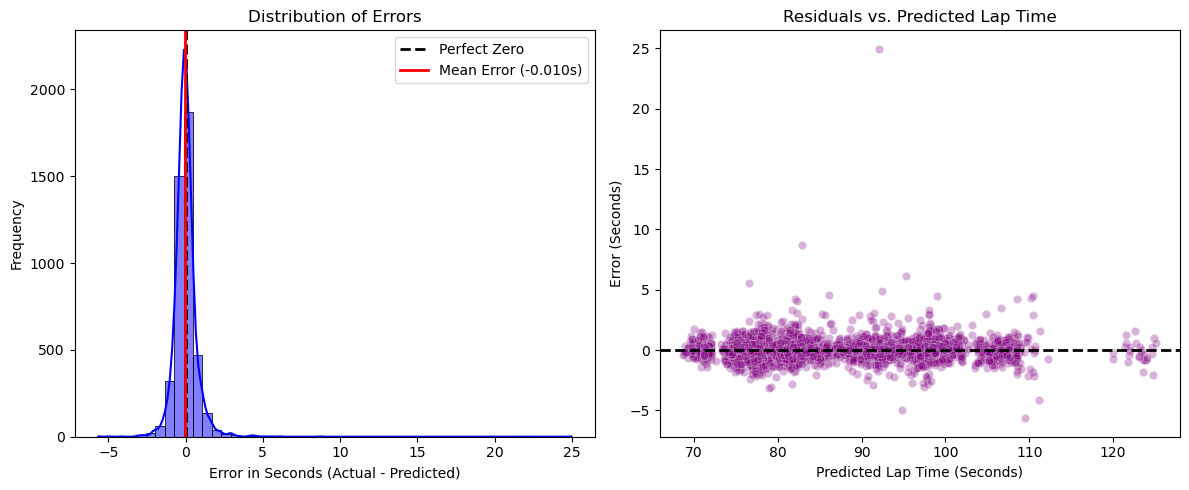

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Generate predictions for the test set
y_pred = xgb_model.predict(X_test)

# 2. Calculate raw errors (Residuals)
# Positive residual = Model predicted a lap that was too fast
# Negative residual = Model predicted a lap that was too slow
residuals = y_test - y_pred

# 3. Calculate Mean Error (ME)
mean_error = np.mean(residuals)
print(f"Mean Error (ME): {mean_error:.4f} seconds")

# 4. Plot the Residuals
plt.figure(figsize=(12, 5))

# Plot A: Histogram of Residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals, bins=50, kde=True, color='blue')
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Perfect Zero')
plt.axvline(mean_error, color='red', linestyle='-', linewidth=2, label=f'Mean Error ({mean_error:.3f}s)')
plt.title('Distribution of Errors')
plt.xlabel('Error in Seconds (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()

# Plot B: Residuals vs. Predicted Values
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Residuals vs. Predicted Lap Time')
plt.xlabel('Predicted Lap Time (Seconds)')
plt.ylabel('Error (Seconds)')

plt.tight_layout()
plt.show()